# IPL Jersey Team Detection — PML Course Project

**Objective:** Detect IPL players in cricket images and classify their team (CSK, DC, GT, KKR, LSG, MI, PBKS, RR, RCB, SRH) using hand-crafted features — no CNNs.

**Pipeline:**
1. Data Loading & Exploration
2. Auto-Annotation (HSV jersey color heuristic)
3. Feature Extraction (HSV histogram + HOG + LBP + color moments)
4. Model Training & Comparison
5. Evaluation & Analysis
6. CSV Output Generation

In [1]:
import os, warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from tqdm import tqdm
from skimage.feature import hog, local_binary_pattern
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_ROOT   = r"C:\Manisha\DS\Project\data"
OUTPUT_DIR  = r"C:\Manisha\DS\Project\output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Image / grid constants ──────────────────────────────────────────────────
IMG_W, IMG_H    = 800, 600
GRID_R, GRID_C  = 8, 8
CELL_W = IMG_W // GRID_C   # 100 px
CELL_H = IMG_H // GRID_R   # 75 px
N_CELLS = GRID_R * GRID_C  # 64

# ── Team label map ─────────────────────────────────────────────────────────
TEAM_LABELS = {
    'NO_PLAYER': 0, 'CSK': 1, 'DC': 2,  'GT': 3,  'KKR': 4,
    'LSG': 5,       'MI': 6, 'PBKS': 7, 'RR': 8,  'RCB': 9, 'SRH': 10
}
LABEL_TO_TEAM = {v: k for k, v in TEAM_LABELS.items()}

TEAM_NAME = "Group_MSSH"   # ← change to your team name before saving model

print("Setup complete. Output dir:", OUTPUT_DIR)

Setup complete. Output dir: C:\Manisha\DS\Project\output


## 1. Data Loading & Exploration

Total images : 10797
Match folders: 45


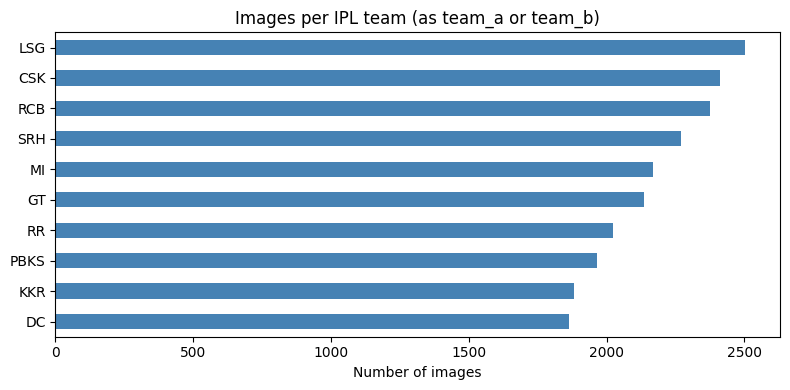

In [2]:
def parse_teams(folder_name):
    """Extract two team abbreviations from folder name e.g. 'CSKvsDC' → ('CSK','DC')."""
    parts = folder_name.split('vs')
    return (parts[0].strip(), parts[1].strip()) if len(parts) == 2 else (None, None)

# Collect all image paths with metadata
records = []
for folder in sorted(os.listdir(DATA_ROOT)):
    folder_path = os.path.join(DATA_ROOT, folder)
    if not os.path.isdir(folder_path):
        continue
    team_a, team_b = parse_teams(folder)
    if team_a is None:
        continue
    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            records.append({
                'path':   os.path.join(folder_path, fname),
                'folder': folder,
                'team_a': team_a,
                'team_b': team_b,
                'fname':  fname
            })

df_images = pd.DataFrame(records)
print(f"Total images : {len(df_images)}")
print(f"Match folders: {df_images['folder'].nunique()}")

# Count per team
team_counts = {}
for t in TEAM_LABELS:
    if t == 'NO_PLAYER':
        continue
    n = df_images[(df_images['team_a'] == t) | (df_images['team_b'] == t)].shape[0]
    team_counts[t] = n

pd.Series(team_counts).sort_values().plot(kind='barh', color='steelblue', figsize=(8,4))
plt.xlabel('Number of images')
plt.title('Images per IPL team (as team_a or team_b)')
plt.tight_layout()
plt.show()

## 2. Grid Visualization

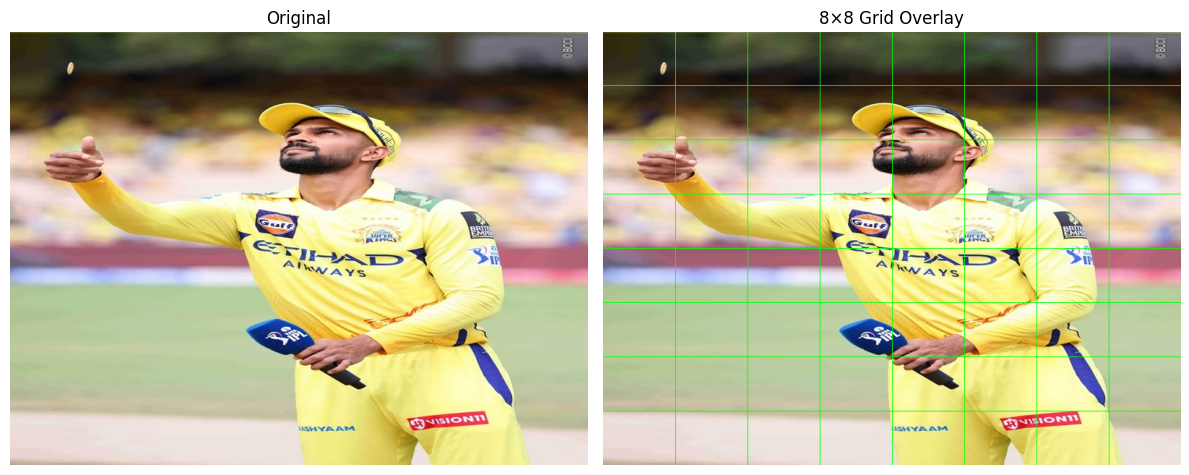

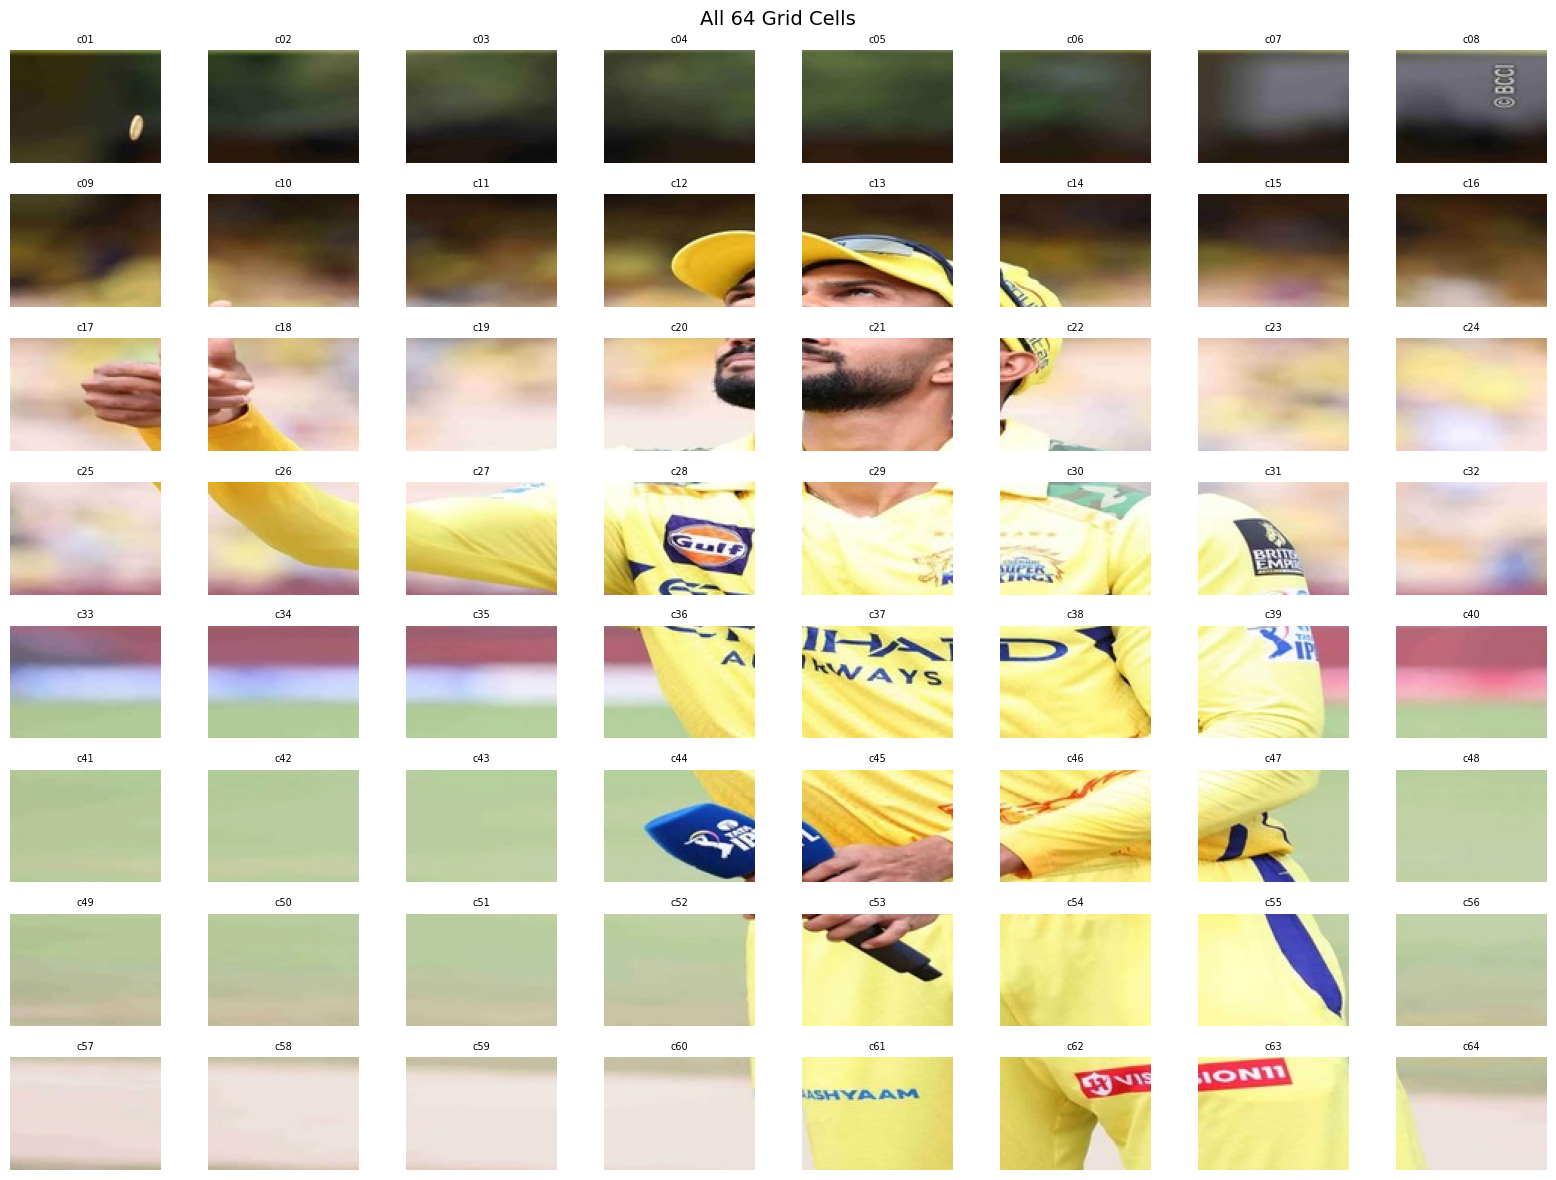

In [3]:
def draw_grid(img, color=(0, 255, 0), thickness=1):
    """Overlay 8×8 grid on image (BGR)."""
    out = img.copy()
    for r in range(1, GRID_R):
        cv2.line(out, (0, r * CELL_H), (IMG_W, r * CELL_H), color, thickness)
    for c in range(1, GRID_C):
        cv2.line(out, (c * CELL_W, 0), (c * CELL_W, IMG_H), color, thickness)
    return out

def split_into_cells(img):
    """Return list of 64 cells (row-major order)."""
    return [
        img[r*CELL_H:(r+1)*CELL_H, c*CELL_W:(c+1)*CELL_W]
        for r in range(GRID_R) for c in range(GRID_C)
    ]

# Show a sample image with grid
sample_path = df_images.iloc[0]['path']
img = cv2.imread(sample_path)
img_grid = draw_grid(img)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_grid, cv2.COLOR_BGR2RGB))
plt.title('8×8 Grid Overlay')
plt.axis('off')
plt.tight_layout()
plt.show()

# Show all 64 cells
cells = split_into_cells(img)
fig, axes = plt.subplots(8, 8, figsize=(16, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(cv2.cvtColor(cells[i], cv2.COLOR_BGR2RGB))
    ax.set_title(f'c{i+1:02d}', fontsize=7)
    ax.axis('off')
plt.suptitle('All 64 Grid Cells', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Auto-Annotation via Jersey HSV Color Heuristic

Since each match folder contains exactly **two known teams**, we reduce labeling to a
3-class problem per image: **Team A / Team B / No Player**.  
We measure what fraction of a cell's pixels fall inside each team's primary jersey HSV range.
The team with higher coverage wins if it exceeds a threshold; otherwise the cell is background (0).

In [4]:
# Primary HSV jersey ranges per team (OpenCV: H 0-180, S/V 0-255)
# Each team can have multiple ranges (list of (lower, upper) pairs)
TEAM_HSV_RANGES = {
    'CSK':  [(np.array([18, 100, 150]), np.array([38, 255, 255]))],          # Yellow/Gold
    'DC':   [(np.array([100,  80,  30]), np.array([130, 255, 180])),         # Navy Blue
             (np.array([  0, 100,  80]), np.array([ 10, 255, 255])),         # Red accent
             (np.array([170, 100,  80]), np.array([180, 255, 255]))],
    'GT':   [(np.array([100,  50,  20]), np.array([125, 220, 170])),         # Navy Blue
             (np.array([ 18,  80, 130]), np.array([ 32, 220, 255]))],        # Gold
    'KKR':  [(np.array([130,  60,  50]), np.array([158, 255, 255])),         # Purple
             (np.array([ 18,  80, 130]), np.array([ 32, 220, 255]))],        # Gold
    'LSG':  [(np.array([ 82, 100, 100]), np.array([100, 255, 255]))],        # Teal/Cyan
    'MI':   [(np.array([100, 130,  80]), np.array([125, 255, 255])),         # Royal Blue
             (np.array([ 18,  80, 130]), np.array([ 32, 220, 255]))],        # Gold
    'PBKS': [(np.array([  0, 120,  80]), np.array([ 12, 255, 255])),         # Red
             (np.array([168, 120,  80]), np.array([180, 255, 255])),         # Red (wrap)
             (np.array([  0,   0, 200]), np.array([180,  30, 255]))],        # White
    'RR':   [(np.array([142,  50, 120]), np.array([172, 255, 255])),         # Pink/Magenta
             (np.array([100,  80,  50]), np.array([130, 255, 200]))],        # Blue
    'RCB':  [(np.array([  0, 100,  50]), np.array([ 12, 255, 200])),         # Red
             (np.array([168, 100,  50]), np.array([180, 255, 200])),         # Red (wrap)
             (np.array([  0,   0,   0]), np.array([180, 255,  50]))],        # Black
    'SRH':  [(np.array([  5, 150, 150]), np.array([ 22, 255, 255])),         # Orange
             (np.array([  0,   0,   0]), np.array([180, 255,  50]))],        # Black
}

COVERAGE_THRESHOLD = 0.08   # cell must have ≥8% team-color pixels to be labeled

def color_coverage(cell_hsv, team):
    """Fraction of pixels in cell matching team's jersey HSV ranges."""
    total = cell_hsv.shape[0] * cell_hsv.shape[1]
    combined = np.zeros(total, dtype=bool)
    flat_hsv = cell_hsv.reshape(-1, 3)
    for lo, hi in TEAM_HSV_RANGES.get(team, []):
        mask = np.all((flat_hsv >= lo) & (flat_hsv <= hi), axis=1)
        combined |= mask
    return combined.sum() / total

def auto_label_cell(cell_bgr, team_a, team_b):
    """Return label for one 100×75 cell given the two teams in the image."""
    cell_hsv = cv2.cvtColor(cell_bgr, cv2.COLOR_BGR2HSV)
    cov_a = color_coverage(cell_hsv, team_a)
    cov_b = color_coverage(cell_hsv, team_b)
    if cov_a < COVERAGE_THRESHOLD and cov_b < COVERAGE_THRESHOLD:
        return 0
    if cov_a >= cov_b:
        return TEAM_LABELS[team_a]
    return TEAM_LABELS[team_b]

# Quick sanity check on sample image
row = df_images.iloc[0]
img = cv2.imread(row['path'])
cells = split_into_cells(img)
labels_sample = [auto_label_cell(c, row['team_a'], row['team_b']) for c in cells]
print(f"Sample image: {row['fname']}  ({row['team_a']} vs {row['team_b']})")
print(f"Label distribution: {pd.Series(labels_sample).value_counts().to_dict()}")

Sample image: CSKvsDC_image_0.jpg  (CSK vs DC)
Label distribution: {0: 37, 1: 20, 2: 7}


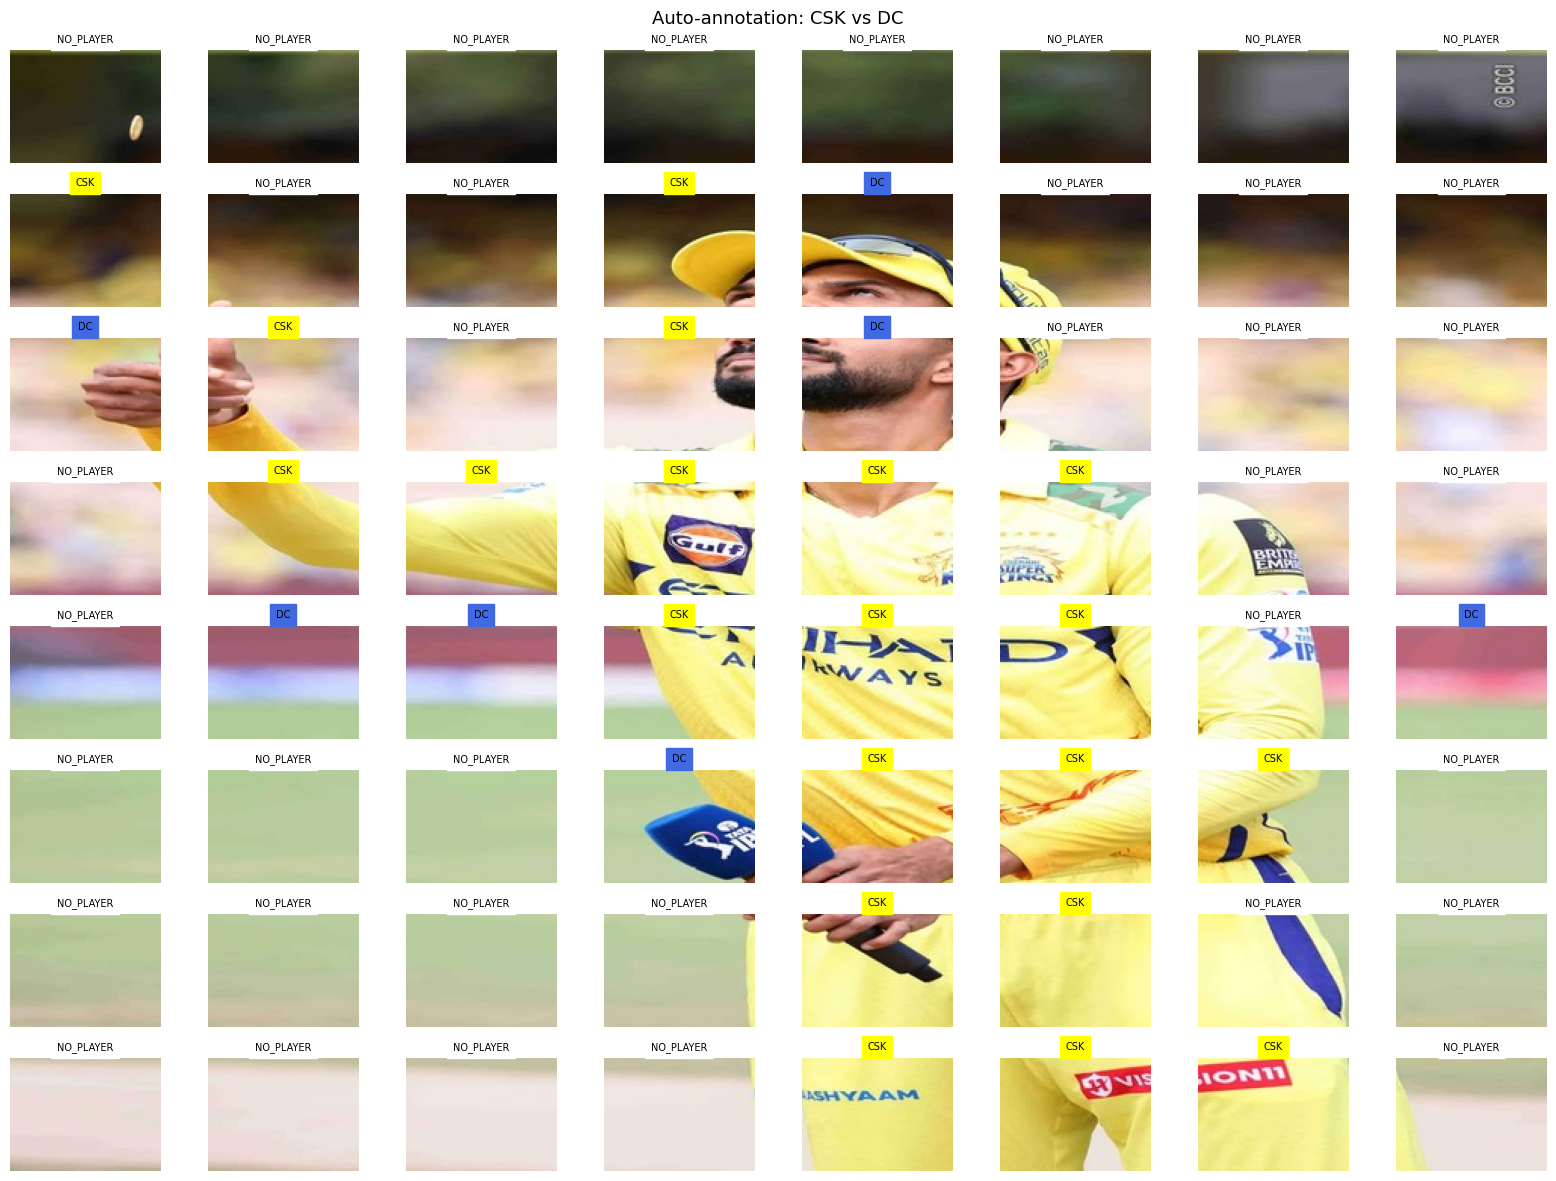

In [5]:
# Visualize auto-annotation on sample image
fig, axes = plt.subplots(8, 8, figsize=(16, 12))
team_colors = {
    0: 'white', 1: 'yellow', 2: 'royalblue', 3: 'navy',
    4: 'purple', 5: 'teal', 6: 'blue', 7: 'red',
    8: 'pink', 9: 'firebrick', 10: 'orange'
}
for i, ax in enumerate(axes.flat):
    ax.imshow(cv2.cvtColor(cells[i], cv2.COLOR_BGR2RGB))
    lbl = labels_sample[i]
    ax.set_title(LABEL_TO_TEAM[lbl], fontsize=7,
                 color='black', backgroundcolor=team_colors.get(lbl, 'white'))
    ax.axis('off')
plt.suptitle(f"Auto-annotation: {row['team_a']} vs {row['team_b']}", fontsize=13)
plt.tight_layout()
plt.show()

Running auto-annotation (this takes ~5-10 min for 10K images)...


100%|██████████| 10797/10797 [14:41<00:00, 12.25it/s]


Annotations saved → C:\Manisha\DS\Project\output\annotations.csv
Annotated images: 10797


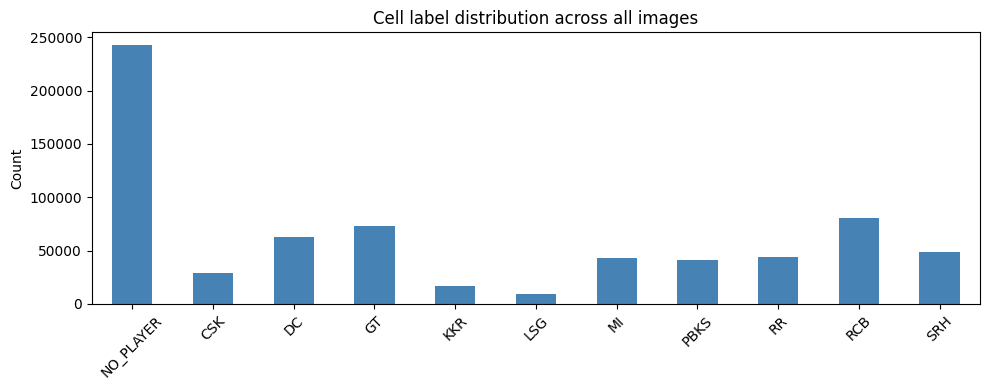

NO_PLAYER    242561
CSK           28674
DC            62781
GT            73120
KKR           16875
LSG            9247
MI            43376
PBKS          41325
RR            43805
RCB           80511
SRH           48733
Name: count, dtype: int64


In [6]:
ANNOT_FILE = os.path.join(OUTPUT_DIR, 'annotations.csv')

if os.path.exists(ANNOT_FILE):
    print("Loading saved annotations...")
    df_annot = pd.read_csv(ANNOT_FILE)
else:
    print("Running auto-annotation (this takes ~5-10 min for 10K images)...")
    rows = []
    for _, row in tqdm(df_images.iterrows(), total=len(df_images)):
        img = cv2.imread(row['path'])
        if img is None:
            continue
        img = cv2.resize(img, (IMG_W, IMG_H))
        cells = split_into_cells(img)
        labels = [auto_label_cell(c, row['team_a'], row['team_b']) for c in cells]
        rec = {'path': row['path'], 'fname': row['fname'],
               'folder': row['folder'], 'team_a': row['team_a'], 'team_b': row['team_b']}
        for ci, lbl in enumerate(labels):
            rec[f'c{ci+1:02d}'] = lbl
        rows.append(rec)
    df_annot = pd.DataFrame(rows)
    df_annot.to_csv(ANNOT_FILE, index=False)
    print(f"Annotations saved → {ANNOT_FILE}")

print(f"Annotated images: {len(df_annot)}")

# Label distribution across all cells
cell_cols = [f'c{i:02d}' for i in range(1, 65)]
all_labels = df_annot[cell_cols].values.flatten()
label_dist = pd.Series(all_labels).value_counts().sort_index()
label_dist.index = [LABEL_TO_TEAM[i] for i in label_dist.index]
label_dist.plot(kind='bar', color='steelblue', figsize=(10, 4))
plt.title('Cell label distribution across all images')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(label_dist)

## 4. Feature Extraction

For each **100×75** cell we extract 338 hand-crafted features:

| Feature | Dims | Rationale |
|---------|------|-----------|
| HSV histogram (H: 36 bins, S: 32, V: 32) | 100 | Primary discriminator — jersey color |
| Color moments (mean+std for BGR & HSV, 6 ch) | 12 | Compact color summary |
| HOG (25×25 cells, 2×2 blocks, 9 orient.) | 216 | Shape/texture — stripe patterns |
| LBP histogram (radius=1, uniform, 10 bins) | 10 | Micro-texture — jersey weave |
| **Total** | **338** | |

In [7]:
def extract_features(cell_bgr):
    """Extract 338 hand-crafted features from a single 100×75 BGR cell."""
    # ── HSV color histogram ──────────────────────────────────────────────
    hsv = cv2.cvtColor(cell_bgr, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv], [0], None, [36], [0, 180]).flatten()
    s_hist = cv2.calcHist([hsv], [1], None, [32], [0, 256]).flatten()
    v_hist = cv2.calcHist([hsv], [2], None, [32], [0, 256]).flatten()
    # Normalize histograms
    n_pixels = cell_bgr.shape[0] * cell_bgr.shape[1]
    h_hist /= (n_pixels + 1e-7)
    s_hist /= (n_pixels + 1e-7)
    v_hist /= (n_pixels + 1e-7)

    # ── Color moments (mean + std) for BGR and HSV ───────────────────────
    moments = []
    for ch_img in [cell_bgr, hsv]:
        for ch in range(3):
            ch_vals = ch_img[:, :, ch].astype(np.float32)
            moments.extend([ch_vals.mean(), ch_vals.std()])
    color_moments = np.array(moments, dtype=np.float32)  # 12 values

    # ── HOG ─────────────────────────────────────────────────────────────
    gray = cv2.cvtColor(cell_bgr, cv2.COLOR_BGR2GRAY)
    hog_feat = hog(gray, orientations=9,
                   pixels_per_cell=(25, 25),
                   cells_per_block=(2, 2),
                   feature_vector=True).astype(np.float32)  # 216 values

    # ── LBP texture histogram ────────────────────────────────────────────
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
    lbp_hist = lbp_hist.astype(np.float32)  # 10 values

    return np.concatenate([h_hist, s_hist, v_hist, color_moments, hog_feat, lbp_hist])

# Verify shape
test_cell = np.zeros((CELL_H, CELL_W, 3), dtype=np.uint8)
feat = extract_features(test_cell)
print(f"Feature vector length: {feat.shape[0]}")  # Should be 338

Feature vector length: 338


In [ ]:
FEAT_FILE  = os.path.join(OUTPUT_DIR, 'features.npz')
LABEL_FILE = os.path.join(OUTPUT_DIR, 'labels.npy')
META_FILE  = os.path.join(OUTPUT_DIR, 'meta.csv')   # image-level split info

if os.path.exists(FEAT_FILE) and os.path.exists(LABEL_FILE):
    print("Loading saved features...")
    X = np.load(FEAT_FILE)['X']
    y = np.load(LABEL_FILE)
    df_meta = pd.read_csv(META_FILE)
else:
    print("Extracting features (this may take 20-40 min for all images)...")
    X_list, y_list, meta_rows = [], [], []

    for idx, row in tqdm(df_annot.iterrows(), total=len(df_annot)):
        img = cv2.imread(row['path'])
        if img is None:
            continue
        img = cv2.resize(img, (IMG_W, IMG_H))
        cells = split_into_cells(img)

        for ci, cell in enumerate(cells):
            col = f'c{ci+1:02d}'
            label = int(row[col])
            feat  = extract_features(cell)
            X_list.append(feat)
            y_list.append(label)

        meta_rows.append({'path': row['path'], 'fname': row['fname'],
                          'folder': row['folder'],
                          'img_idx': idx})

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    df_meta = pd.DataFrame(meta_rows)

    np.savez_compressed(FEAT_FILE, X=X)
    np.save(LABEL_FILE, y)
    df_meta.to_csv(META_FILE, index=False)
    print(f"Saved features → {FEAT_FILE}")

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Class distribution: {pd.Series(y).value_counts().sort_index().to_dict()}")

Extracting features (this may take 20-40 min for all images)...


 25%|██▌       | 2746/10797 [09:43<22:29,  5.97it/s]  

## 5. Train / Test Split

We split at the **image level** (not cell level) to prevent data leakage — cells from the same image are highly correlated.

In [ ]:
# Split images (not cells) 80/20 stratified by folder
img_indices = np.arange(len(df_meta))
folders = df_meta['folder'].values

from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_img_idx, test_img_idx = next(gss.split(img_indices, groups=folders))

# Map image indices to cell indices (each image = 64 cells)
train_cell_mask = np.isin(np.arange(len(y)) // N_CELLS, train_img_idx)
test_cell_mask  = ~train_cell_mask

X_train, y_train = X[train_cell_mask], y[train_cell_mask]
X_test,  y_test  = X[test_cell_mask],  y[test_cell_mask]

# Store split info for CSV generation later
df_meta['split'] = 'test'
df_meta.loc[df_meta.index.isin(train_img_idx), 'split'] = 'train'
df_meta.to_csv(META_FILE, index=False)

print(f"Train cells: {len(X_train):,}  ({len(train_img_idx)} images)")
print(f"Test  cells: {len(X_test):,}  ({len(test_img_idx)} images)")
print(f"\nTrain class dist: {pd.Series(y_train).value_counts().sort_index().to_dict()}")
print(f"Test  class dist: {pd.Series(y_test).value_counts().sort_index().to_dict()}")

## 6. Model Training & Comparison

We compare three classifiers with `class_weight='balanced'` to handle the large background class.

In [ ]:
# ── Random Forest ────────────────────────────────────────────────────────
print("Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc  = accuracy_score(y_test,  rf.predict(X_test))
print(f"RF  — Train Acc: {rf_train_acc:.4f}  |  Test Acc: {rf_test_acc:.4f}")

In [ ]:
# ── XGBoost ──────────────────────────────────────────────────────────────
print("Training XGBoost...")

# Compute class weights manually for XGBoost
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42
)
xgb_clf.fit(X_train, y_train, sample_weight=sample_weights,
            eval_set=[(X_test, y_test)], verbose=50)

xgb_train_acc = accuracy_score(y_train, xgb_clf.predict(X_train))
xgb_test_acc  = accuracy_score(y_test,  xgb_clf.predict(X_test))
print(f"XGB — Train Acc: {xgb_train_acc:.4f}  |  Test Acc: {xgb_test_acc:.4f}")

In [ ]:
# ── SVM (on a subset — SVM is slow on very large datasets) ───────────────
print("Training SVM (on 50K sample)...")
MAX_SVM = 50_000
rng = np.random.default_rng(42)
svm_idx = rng.choice(len(X_train), size=min(MAX_SVM, len(X_train)), replace=False)

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale',
                class_weight='balanced', decision_function_shape='ovr'))
])
svm_pipe.fit(X_train[svm_idx], y_train[svm_idx])

svm_test_acc = accuracy_score(y_test, svm_pipe.predict(X_test))
print(f"SVM — Test Acc: {svm_test_acc:.4f}  (trained on {len(svm_idx):,} samples)")

In [ ]:
# ── Summary comparison ────────────────────────────────────────────────────
results = pd.DataFrame([
    {'Model': 'Random Forest', 'Train Acc': rf_train_acc,  'Test Acc': rf_test_acc},
    {'Model': 'XGBoost',       'Train Acc': xgb_train_acc, 'Test Acc': xgb_test_acc},
    {'Model': 'SVM (50K)',     'Train Acc': None,           'Test Acc': svm_test_acc},
])
print(results.to_string(index=False))

results.set_index('Model')[['Train Acc', 'Test Acc']].plot(
    kind='bar', figsize=(8, 4), ylim=(0, 1), color=['steelblue', 'coral'])
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 7. Detailed Evaluation — Best Model

In [ ]:
# Pick best model by test accuracy
best_name, best_model = max(
    [('Random Forest', rf), ('XGBoost', xgb_clf), ('SVM', svm_pipe)],
    key=lambda nm: accuracy_score(y_test, nm[1].predict(X_test))
)
print(f"Best model: {best_name}")

y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

target_names = [LABEL_TO_TEAM[i] for i in sorted(LABEL_TO_TEAM)]

print("\n── Train Classification Report ──")
print(classification_report(y_train, y_pred_train, target_names=target_names, zero_division=0))

print("\n── Test Classification Report ──")
print(classification_report(y_test, y_pred_test, target_names=target_names, zero_division=0))

In [ ]:
# Confusion matrix (test set)
cm = confusion_matrix(y_test, y_pred_test, labels=sorted(LABEL_TO_TEAM))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=[LABEL_TO_TEAM[i] for i in sorted(LABEL_TO_TEAM)])
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
plt.title(f'Confusion Matrix — {best_name} (Test Set)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

In [ ]:
# Feature importance (Random Forest)
if hasattr(rf, 'feature_importances_'):
    importance = rf.feature_importances_
    # Group by feature type
    groups = [
        ('H-hist (36)',   slice(0, 36)),
        ('S-hist (32)',   slice(36, 68)),
        ('V-hist (32)',   slice(68, 100)),
        ('ColorMoments (12)', slice(100, 112)),
        ('HOG (216)',     slice(112, 328)),
        ('LBP (10)',      slice(328, 338)),
    ]
    group_imp = {name: importance[sl].sum() for name, sl in groups}
    pd.Series(group_imp).sort_values().plot(kind='barh', figsize=(7, 4), color='steelblue')
    plt.title('RF Feature Group Importance')
    plt.xlabel('Total importance')
    plt.tight_layout()
    plt.show()

## 8. Save Best Model

In [ ]:
model_path = os.path.join(OUTPUT_DIR, f'model_{TEAM_NAME}.pkl')

# Bundle model with metadata for easy inference
model_bundle = {
    'model':        best_model,
    'model_name':   best_name,
    'team_labels':  TEAM_LABELS,
    'label_to_team': LABEL_TO_TEAM,
    'img_w': IMG_W, 'img_h': IMG_H,
    'cell_w': CELL_W, 'cell_h': CELL_H,
    'grid_r': GRID_R, 'grid_c': GRID_C,
    'train_acc': accuracy_score(y_train, y_pred_train),
    'test_acc':  accuracy_score(y_test,  y_pred_test),
}

joblib.dump(model_bundle, model_path)
print(f"Model saved → {model_path}")
print(f"Train accuracy : {model_bundle['train_acc']:.4f}")
print(f"Test  accuracy : {model_bundle['test_acc']:.4f}")

## 9. Generate Predictions CSV

Format: `Image File Name, Train Or Test, c01, c02, …, c64`

In [ ]:
CSV_FILE = os.path.join(OUTPUT_DIR, f'predictions_{TEAM_NAME}.csv')

csv_rows = []

for _, row in tqdm(df_meta.iterrows(), total=len(df_meta)):
    img = cv2.imread(row['path'])
    if img is None:
        continue
    img = cv2.resize(img, (IMG_W, IMG_H))
    cells = split_into_cells(img)

    cell_feats = np.array([extract_features(c) for c in cells], dtype=np.float32)
    preds = best_model.predict(cell_feats)

    rec = {'Image File Name': row['fname'],
           'Train Or Test':   'Train' if row['split'] == 'train' else 'Test'}
    for ci, pred in enumerate(preds):
        rec[f'c{ci+1:02d}'] = int(pred)
    csv_rows.append(rec)

df_csv = pd.DataFrame(csv_rows)
df_csv.to_csv(CSV_FILE, index=False)
print(f"Predictions saved → {CSV_FILE}")
print(f"Shape: {df_csv.shape}")
df_csv.head(3)

In [ ]:
# Validate CSV format
expected_cols = ['Image File Name', 'Train Or Test'] + [f'c{i:02d}' for i in range(1, 65)]
assert list(df_csv.columns) == expected_cols, "Column mismatch!"
assert df_csv['Train Or Test'].isin(['Train', 'Test']).all(), "Invalid split labels!"
assert df_csv.iloc[:, 2:].isin(range(11)).all().all(), "Invalid prediction values!"
print("CSV validation passed.")
print(f"Train images: {(df_csv['Train Or Test']=='Train').sum()}")
print(f"Test  images: {(df_csv['Train Or Test']=='Test').sum()}")

## 10. Inference on a Single New Image

This function shows how the pipeline code should work — load `.pkl`, accept one image path, return predictions.

In [ ]:
def predict_image(image_path, model_pkl_path):
    """
    Load saved model and predict team labels for all 64 grid cells of an image.

    Args:
        image_path    : path to an 800×600 (or any) image
        model_pkl_path: path to model_<teamname>.pkl

    Returns:
        dict with keys 'fname', 'predictions' (list[64] of int), 'labels' (list[64] of str)
    """
    bundle = joblib.load(model_pkl_path)
    model  = bundle['model']
    label_to_team = bundle['label_to_team']
    img_w, img_h  = bundle['img_w'], bundle['img_h']
    cell_w, cell_h = bundle['cell_w'], bundle['cell_h']
    grid_r, grid_c = bundle['grid_r'], bundle['grid_c']

    img = cv2.imread(image_path)
    assert img is not None, f"Cannot read image: {image_path}"
    img = cv2.resize(img, (img_w, img_h))

    cells = [
        img[r*cell_h:(r+1)*cell_h, c*cell_w:(c+1)*cell_w]
        for r in range(grid_r) for c in range(grid_c)
    ]
    feats = np.array([extract_features(cell) for cell in cells], dtype=np.float32)
    preds = model.predict(feats).tolist()

    return {
        'fname':       os.path.basename(image_path),
        'predictions': preds,
        'labels':      [label_to_team[p] for p in preds]
    }

# Test on a sample image
result = predict_image(df_images.iloc[0]['path'], model_path)
print(f"Image  : {result['fname']}")
print(f"Unique teams detected: {set(result['labels'])}")

# Visualize predictions on grid
img = cv2.imread(df_images.iloc[0]['path'])
img = cv2.resize(img, (IMG_W, IMG_H))
cells = split_into_cells(img)

fig, axes = plt.subplots(8, 8, figsize=(16, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(cv2.cvtColor(cells[i], cv2.COLOR_BGR2RGB))
    lbl = result['labels'][i]
    ax.set_title(lbl, fontsize=7,
                 color='black', backgroundcolor=team_colors.get(result['predictions'][i], 'white'))
    ax.axis('off')
plt.suptitle(f"Predictions: {result['fname']}", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Performance Metrics Summary

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

metrics = {
    'Split':     ['Train', 'Test'],
    'Accuracy':  [accuracy_score(y_train, y_pred_train),
                  accuracy_score(y_test,  y_pred_test)],
    'F1 (macro)': [f1_score(y_train, y_pred_train, average='macro', zero_division=0),
                   f1_score(y_test,  y_pred_test,  average='macro', zero_division=0)],
    'F1 (weighted)': [f1_score(y_train, y_pred_train, average='weighted', zero_division=0),
                      f1_score(y_test,  y_pred_test,  average='weighted', zero_division=0)],
}
df_metrics = pd.DataFrame(metrics)
print(df_metrics.to_string(index=False))
df_metrics.to_csv(os.path.join(OUTPUT_DIR, 'metrics.csv'), index=False)
print(f"\nSaved metrics → {os.path.join(OUTPUT_DIR, 'metrics.csv')}")

## Deliverables Checklist

| Deliverable | File | Status |
|-------------|------|--------|
| Dataset | `data/` folders + `output/annotations.csv` | ✓ |
| Source Code | `project.ipynb` | ✓ |
| Model Weights | `output/model_<teamname>.pkl` | ✓ |
| Pipeline Code | `pipeline.py` | ✓ |
| Predictions CSV | `output/predictions_<teamname>.csv` | ✓ |
| Performance Metrics | `output/metrics.csv` | ✓ |
| Presentation | Slides (to be prepared) | — |
| Video | ~5 min walkthrough (to be recorded) | — |